# CLassify Medium Articles with Embeddings

https://www.nlplanet.org/course-practical-nlp/01-intro-to-nlp/13-classify-articles-embeddings

In [2]:
from huggingface_hub import hf_hub_download

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
  ConfusionMatrixDisplay)

Download the dataset

In [3]:
# download dataset of Medium articles from
# https://huggingface.co/datasets/fabiochiu/medium-articles
df_articles = pd.read_csv(
  hf_hub_download("fabiochiu/medium-articles", repo_type="dataset", filename="medium_articles.csv")
)

df_articles.head()

,title,text,url,authors,timestamp,tags
0,Mental Note Vol. 24,Photo by Josh Riemer on Unsplash\n\nMerry Chri...,https://medium.com/invisible-illness/mental-no...,['Ryan Fan'],2020-12-26 03:38:10.479000+00:00,"['Mental Health', 'Health', 'Psychology', 'Sci..."
1,Your Brain On Coronavirus,Your Brain On Coronavirus\n\nA guide to the cu...,https://medium.com/age-of-awareness/how-the-pa...,['Simon Spichak'],2020-09-23 22:10:17.126000+00:00,"['Mental Health', 'Coronavirus', 'Science', 'P..."
2,Mind Your Nose,Mind Your Nose\n\nHow smell training can chang...,https://medium.com/neodotlife/mind-your-nose-f...,[],2020-10-10 20:17:37.132000+00:00,"['Biotechnology', 'Neuroscience', 'Brain', 'We..."
3,The 4 Purposes of Dreams,Passionate about the synergy between science a...,https://medium.com/science-for-real/the-4-purp...,['Eshan Samaranayake'],2020-12-21 16:05:19.524000+00:00,"['Health', 'Neuroscience', 'Mental Health', 'P..."
4,Surviving a Rod Through the Head,"You’ve heard of him, haven’t you? Phineas Gage...",https://medium.com/live-your-life-on-purpose/s...,['Rishav Sinha'],2020-02-26 00:01:01.576000+00:00,"['Brain', 'Health', 'Development', 'Psychology..."


Text preprocessing and train/test split

In [4]:
#create two columns:
# - full_text: contains the concatenation of the title and the text of the article.
# - is_data_science: a boolean which is True if the article has the "Data Science" tag
df_articles["is_data_science"] = df_articles["tags"] \
  .apply(lambda tags_list: "Data Science" in tags_list)
df_articles["full_text"] = df_articles["title"] + " " + df_articles["text"]
df_articles.head()

,title,text,url,authors,timestamp,tags,is_data_science,full_text
0,Mental Note Vol. 24,Photo by Josh Riemer on Unsplash\n\nMerry Chri...,https://medium.com/invisible-illness/mental-no...,['Ryan Fan'],2020-12-26 03:38:10.479000+00:00,"['Mental Health', 'Health', 'Psychology', 'Sci...",False,Mental Note Vol. 24 Photo by Josh Riemer on Un...
1,Your Brain On Coronavirus,Your Brain On Coronavirus\n\nA guide to the cu...,https://medium.com/age-of-awareness/how-the-pa...,['Simon Spichak'],2020-09-23 22:10:17.126000+00:00,"['Mental Health', 'Coronavirus', 'Science', 'P...",False,Your Brain On Coronavirus Your Brain On Corona...
2,Mind Your Nose,Mind Your Nose\n\nHow smell training can chang...,https://medium.com/neodotlife/mind-your-nose-f...,[],2020-10-10 20:17:37.132000+00:00,"['Biotechnology', 'Neuroscience', 'Brain', 'We...",False,Mind Your Nose Mind Your Nose\n\nHow smell tra...
3,The 4 Purposes of Dreams,Passionate about the synergy between science a...,https://medium.com/science-for-real/the-4-purp...,['Eshan Samaranayake'],2020-12-21 16:05:19.524000+00:00,"['Health', 'Neuroscience', 'Mental Health', 'P...",False,The 4 Purposes of Dreams Passionate about the ...
4,Surviving a Rod Through the Head,"You’ve heard of him, haven’t you? Phineas Gage...",https://medium.com/live-your-life-on-purpose/s...,['Rishav Sinha'],2020-02-26 00:01:01.576000+00:00,"['Brain', 'Health', 'Development', 'Psychology...",False,Surviving a Rod Through the Head You’ve heard ...


In [5]:
# sample 1000 articles is_data_science = True and 1000 articles with
# is_data_science = False
df = pd.concat([
    df_articles[df_articles["is_data_science"]].sample(n=1000),
    df_articles[~df_articles["is_data_science"]].sample(n=1000)
])

In [7]:
# download the sentence embeddings model
embedder = SentenceTransformer('all-MiniLM-L6-v2')

c:\Users\TristramArmour\anaconda3\envs\learning\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [8]:
# embed article texts
corpus = df["full_text"].values
corpus_embeddings = embedder.encode(corpus)
print(corpus_embeddings.shape)

c:\Users\TristramArmour\anaconda3\envs\learning\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


(2000, 384)


In [9]:
# train/test split
X = corpus_embeddings
y = df["is_data_science"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

Model training and evaluation

In [10]:
# train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
# compute predictions on test set
predictions = model.predict(X_test)

# plot precision, recall, f1-score on test set
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.92      0.92      0.92       200
        True       0.92      0.92      0.92       200

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



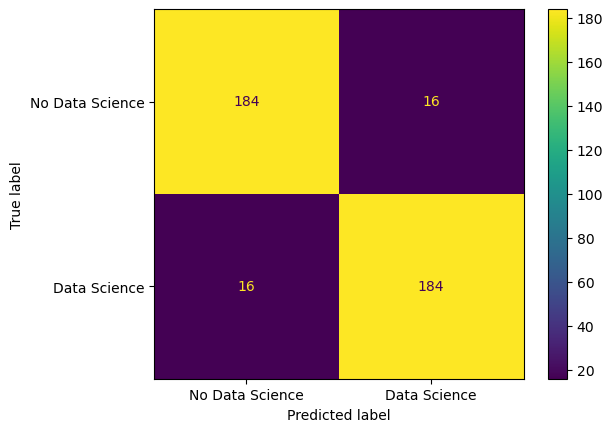

In [12]:
# plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Data Science", "Data Science"])
p = disp.plot()
fig = p.figure_
fig.set_facecolor('white')

Testing the model with custom text

In [13]:
# try the model with custom text
text = "How to deal with precision and recall"
text_embedding = embedder.encode(text)
result = model.predict([text_embedding])[0]
print(result)

True


In [14]:
# try the model with custom text
text = "How to sleep better"
text_embedding = embedder.encode(text)
result = model.predict([text_embedding])[0]
print(result)

False


In [15]:
# It works!